In [1]:
""" Plot the dissolution, pore water cation, and CEC cation balance """
import os
import xarray as xr
from glob import glob
import pandas as pd
import numpy as np
from shared_read_HBR import *
from matplotlib import rcParams
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm
import itertools as it

rcParams['font.size'] = 14
rcParams['axes.titlesize'] = 14

# soil layer depths in ELM
zsoi = np.array([0.0071, 0.0279, 0.0623, 0.1189, 0.2122, 0.3661, 0.6198, 1.0380, 1.7276, 2.8646])
zisoi = np.array([0.0175, 0.0451, 0.0906, 0.1655, 0.2891, 0.4929, 0.8289, 1.3828, 2.2961, 3.8019])
dzsoi = np.array([0.0175, 0.0276, 0.0455, 0.0750, 0.1236, 0.2038, 0.3360, 0.5539, 0.9133, 1.5058])

# major cation list
cations = ['Ca2+','Mg2+','Na+','K+','Al3+']

# minerals list
minerals_name = ['Wollastonite_CaSiO3', 'Forsterite_Mg2SiO4', 'Albite_NaAlSi3O8', 
                 'Anorthite_CaAl2Si2O8', 'Epidote_Ca2FeAl2(SiO4)3(OH)', 'Calcite_CaCO3',
                 'Labradorite_Ca0.6Na0.4Al1.6Si2.4O8', 'Augite_Ca0.9Mg0.9Na0.1Al0.4Fe0.2Si1.9O6',
                 'Kfeldspar_KAlSi3O8', 'Enstatite_MgSiO3']
mineral_list = [2, 7, 8, 9]

# list of NetCDF file names generated by ELM
date_prefix = '20250427'
region = 'conus'
start = 1992 # the year right before application starts
end = 2012 # 20 years after
case_suffix = 'ICB20TRCNPRDCTCBC_3yearerw'

if '1850CN' in case_suffix:
    tvec = pd.date_range(f'{start+2000}-01-01', f'{end+2000}-12-31', freq = '1D')
    tvec_mon = pd.date_range(f'{start+2000}-01-01', f'{end+2000}-12-31', freq = '1MS')
    tvec_yr = pd.date_range(f'{start+2000}-01-01', f'{end+2000}-12-31', freq = '1YS')
else:
    tvec = pd.date_range(f'{start}-01-01', f'{end}-12-31', freq = '1D')
    tvec_mon = pd.date_range(f'{start}-01-01', f'{end}-12-31', freq = '1MS')
    tvec_yr = pd.date_range(f'{start}-01-01', f'{end}-12-31', freq = '1YS')
tvec = tvec[(tvec.month != 2) | (tvec.day != 29)]
case_name = f'{date_prefix}_{region}_{case_suffix}'
file_list = [os.path.join(os.environ['E3SM_ROOT'], 'output', case_name, 'run', 
                          f'{case_name}.elm.h1.{year:04d}-01-01-00000.nc') \
             for year in range(start, end + 1)]

# path to save the graphs
path_out = os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'results', 'plot_conus', case_name)
if not os.path.exists(path_out):
    os.mkdir(os.path.join(path_out))

In [2]:
hr = xr.open_mfdataset(file_list)

In [3]:
lon = hr['lon'].values
lat = hr['lat'].values

/tmp/ipykernel_101403/4183374967.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_101403/4183374967.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_101403/4183374967.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_101403/4183374967.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


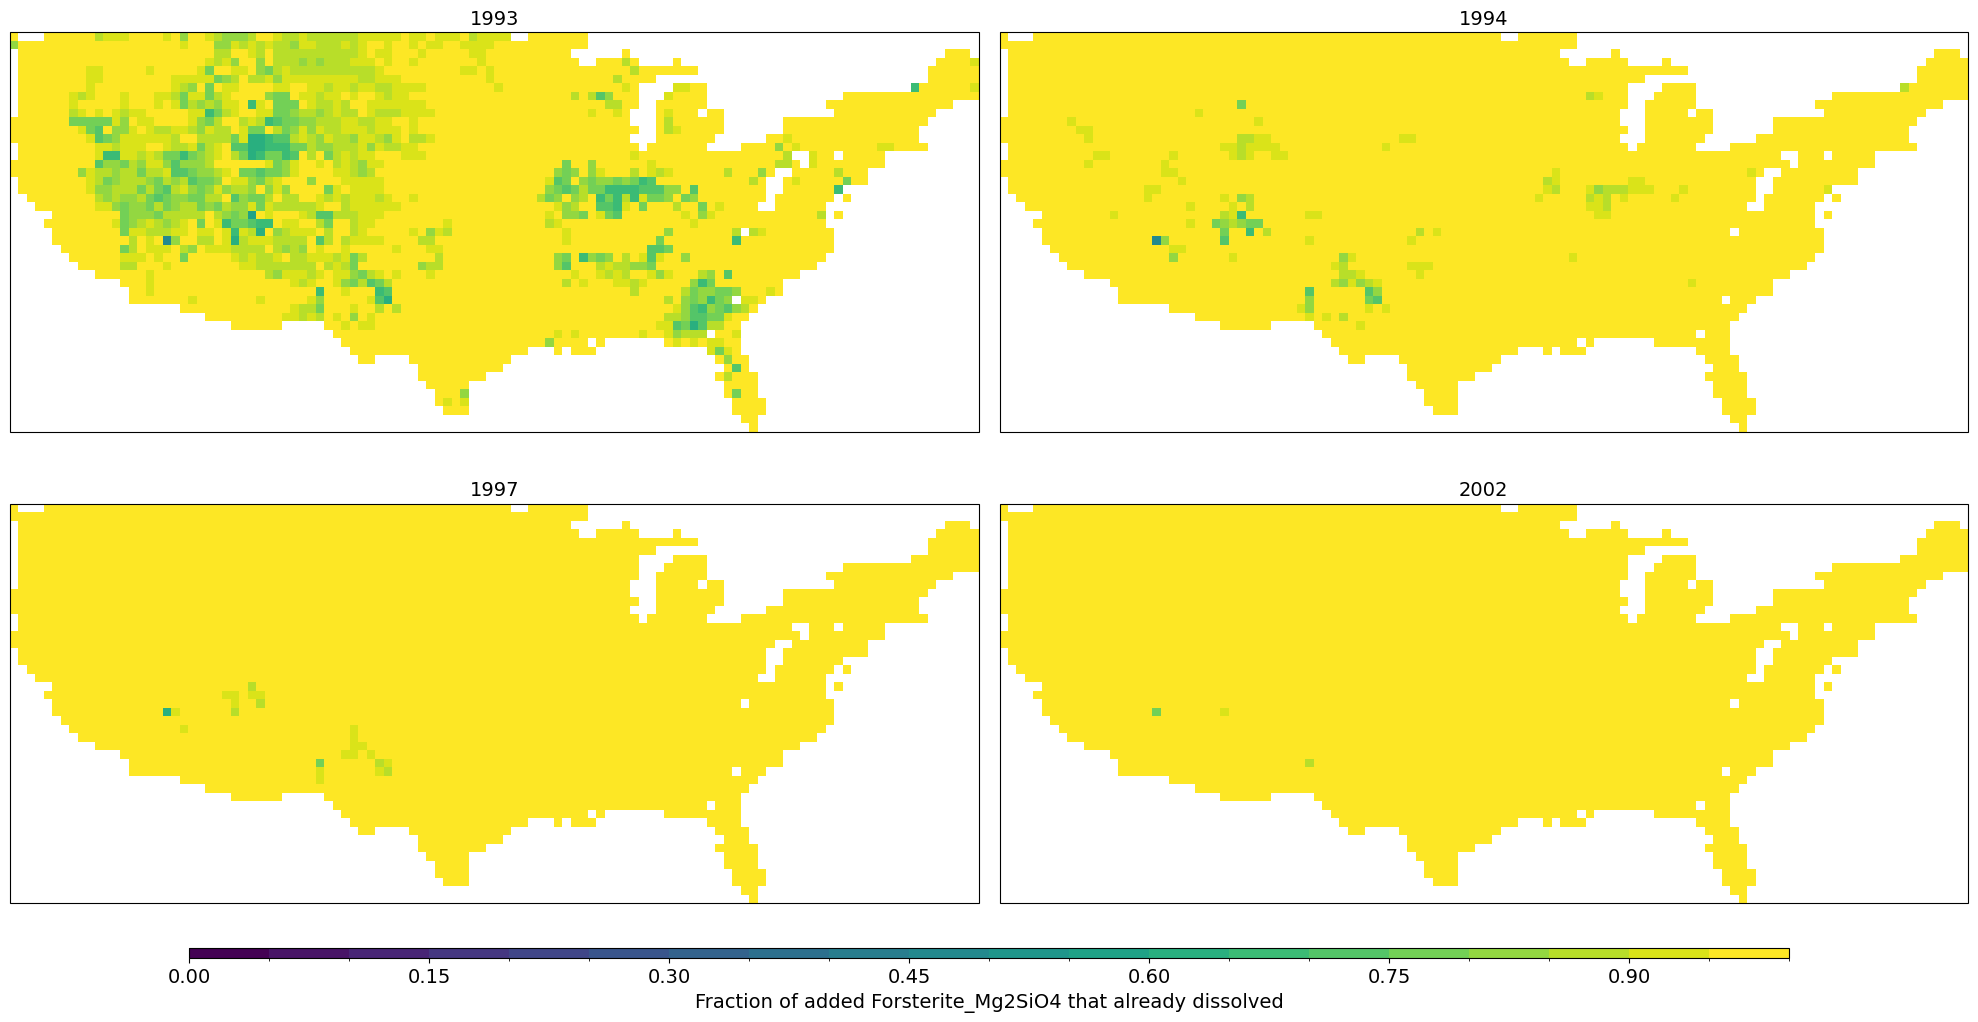

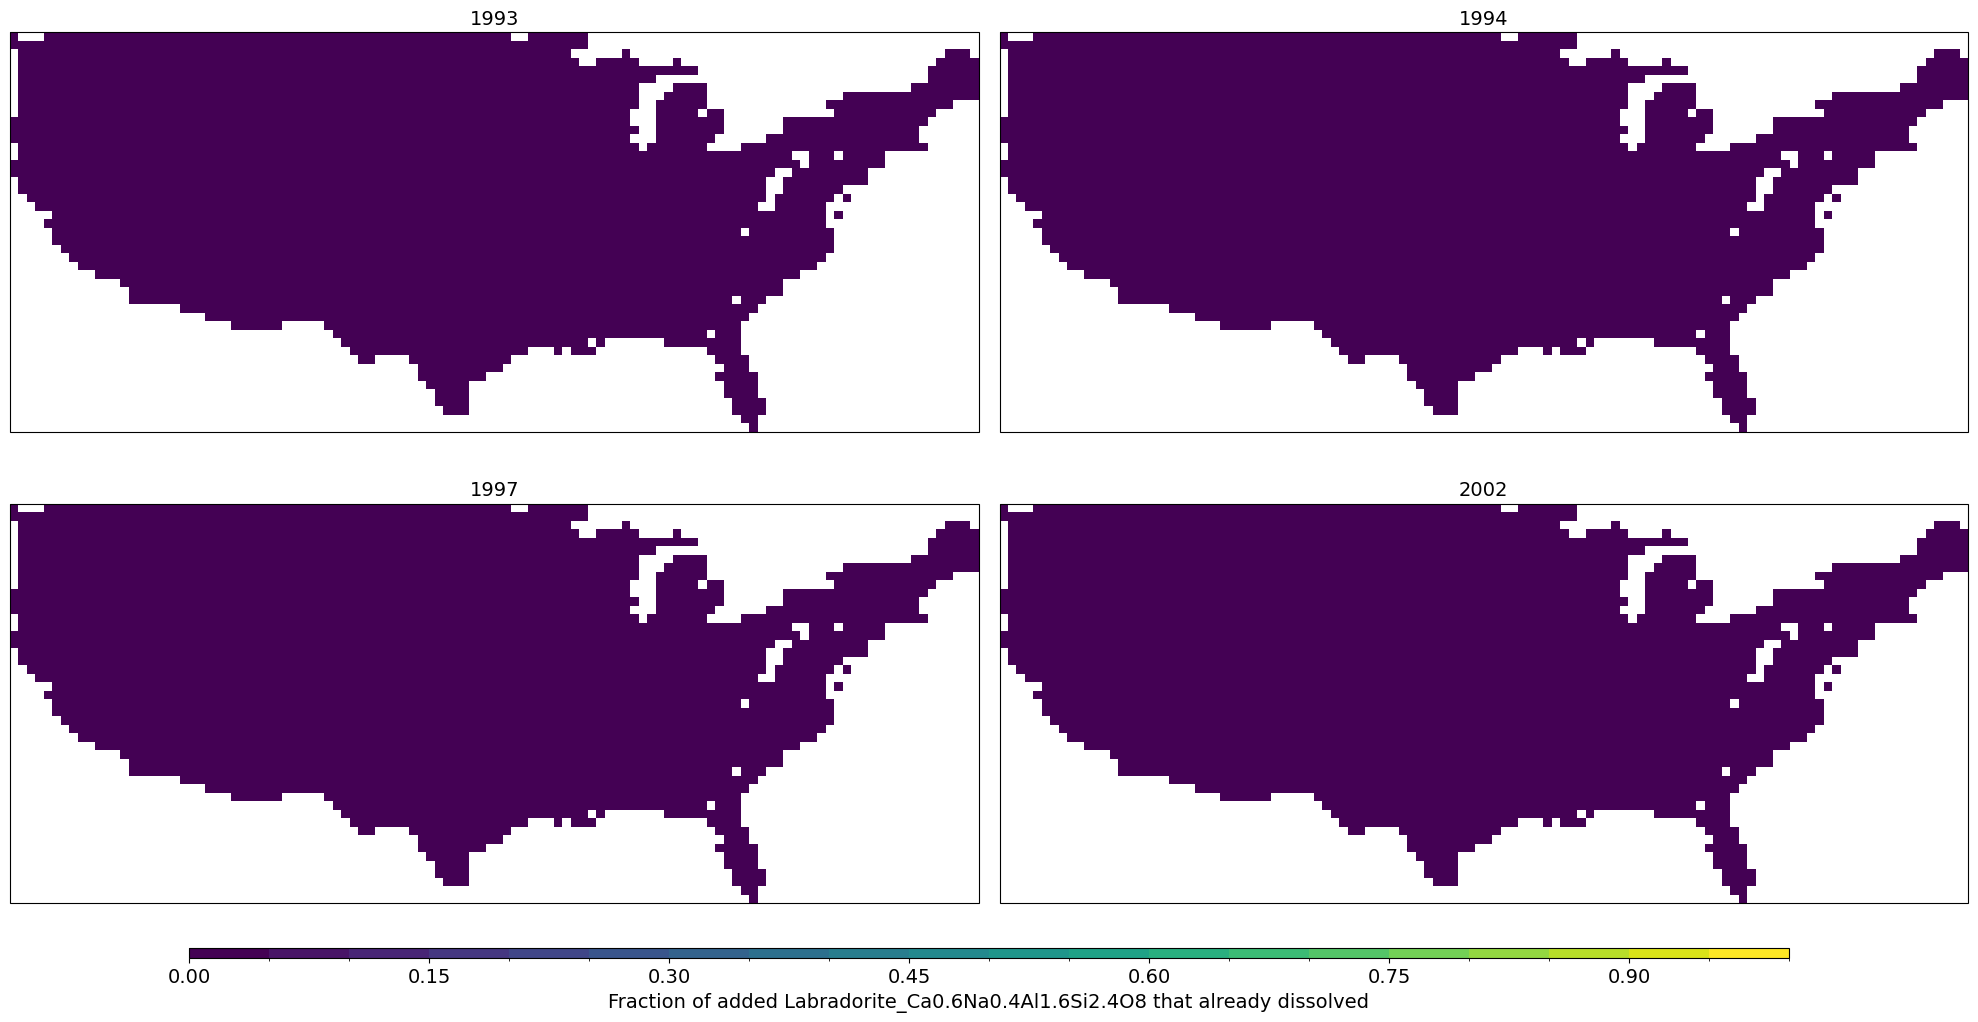

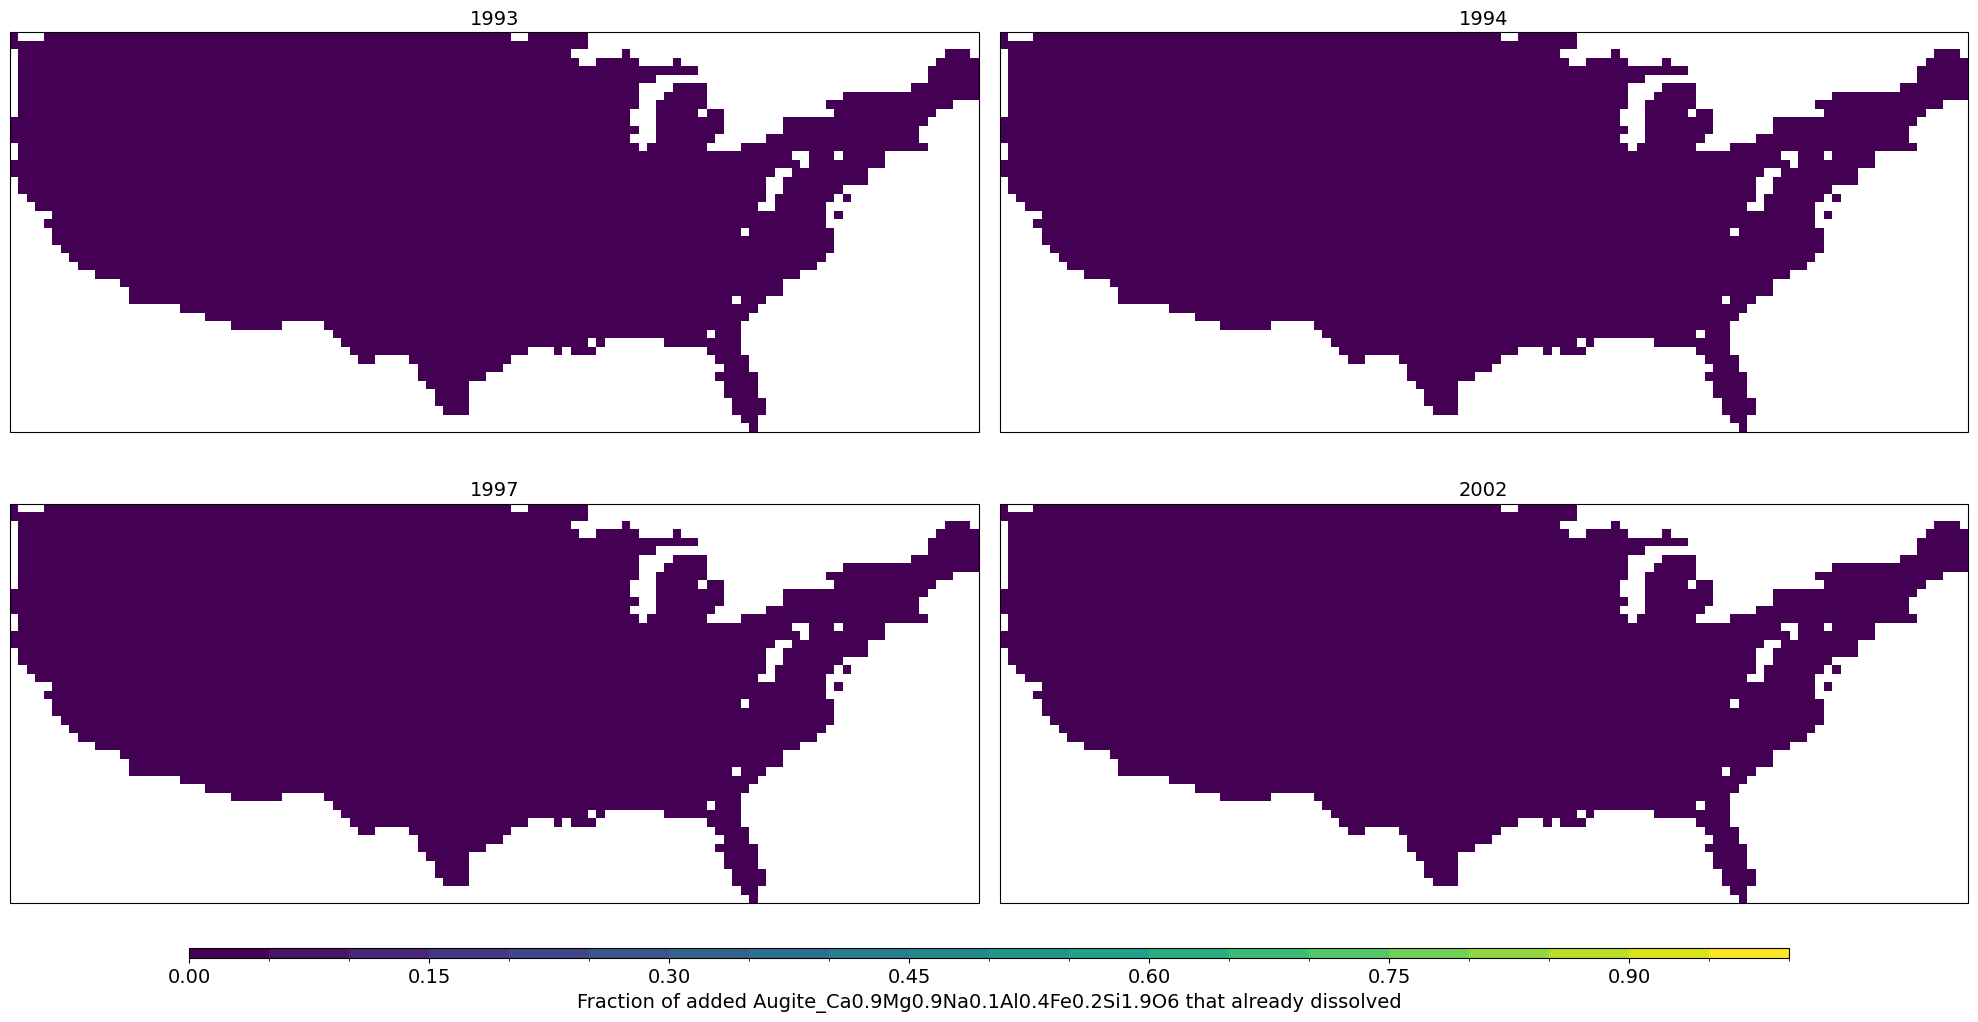

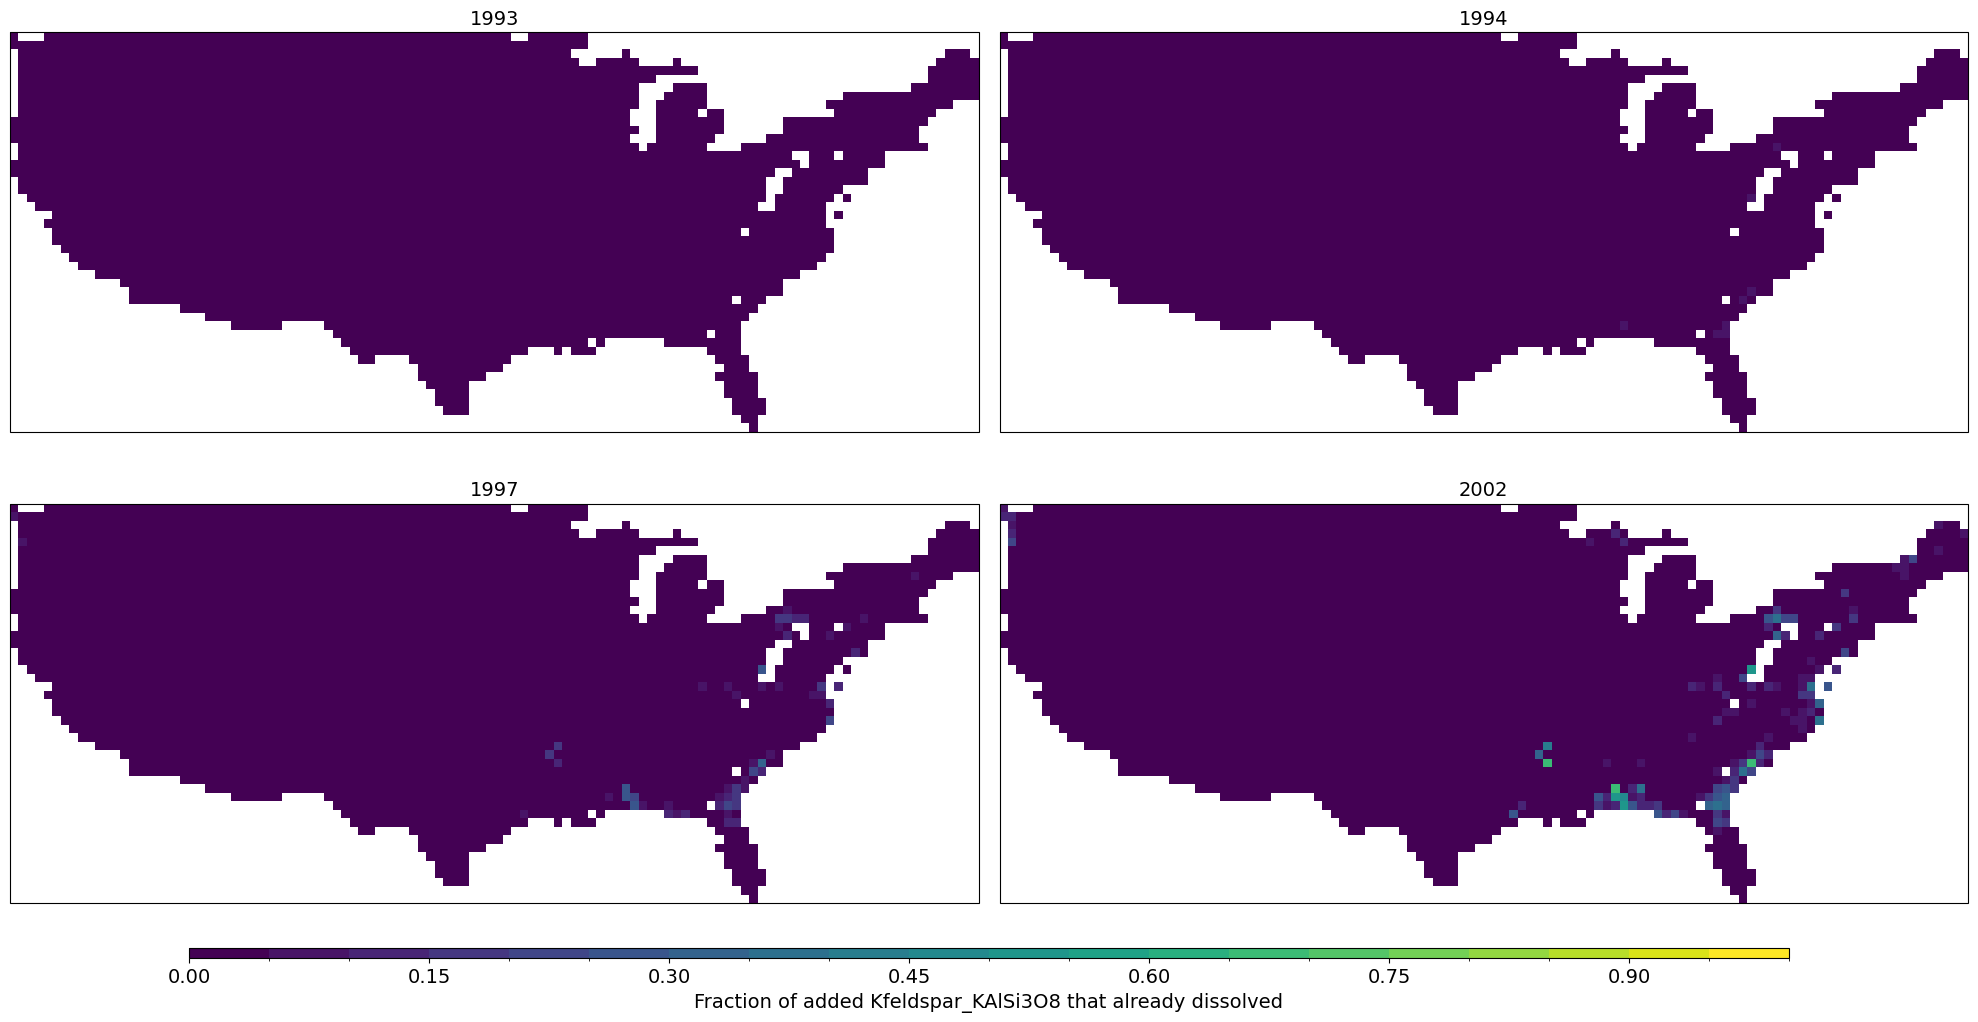

In [4]:
for min in mineral_list:
    # g m-2 s-1 => kg m-2 day-1; sum up over all days
    primary_added = (hr['primary_added'][:, min-1, :, :] * 86400 / 1000
                    ).resample(time='1Y').sum(skipna=False).cumsum(axis = 0, skipna=False)
    primary_dissolve = (hr['primary_dissolve'][:, min-1, :, :] * 86400 / 1000
                        ).resample(time='1Y').sum(skipna=False).cumsum(axis = 0, skipna=False)

    # percentage dissolved
    ratio_dissolve = primary_dissolve / primary_added

    # for 1, 2, 5, 10 years after the application, 
    fig, axes = plt.subplots(2, 2, figsize = (20, 10), 
                            subplot_kw={'projection': ccrs.PlateCarree()})
    for i, year in enumerate([1,2,5,10]):
        ax = axes.flat[i]
        norm = BoundaryNorm(np.linspace(0, 1, 21), ncolors=256, extend='neither')
        cf = ax.pcolormesh(lon, lat, ratio_dissolve[year, :, :], norm=norm, cmap='viridis')
        ax.set_title(f'{year+start}')
    cax = fig.add_axes([0.1,0.01,0.8,0.01])
    plt.colorbar(cf, cax = cax, orientation='horizontal', 
                label = f'Fraction of added {minerals_name[min-1]} that already dissolved')
    plt.tight_layout()